In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = "/content/drive/MyDrive/praktikum_ml/praktikum06"

In [4]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [5]:
df = pd.read_csv(path + '/dataset/student.csv')
df.head()

,Unnamed: 0,Id,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
0,0,5001,21,Male,Other,50%,Yes,No,Private,0,Always,Yes,Yes,No,No,AA
1,1,5002,20,Male,Other,50%,Yes,No,Private,0,Always,Yes,No,Yes,Yes,AA
2,2,5003,21,Male,State,50%,No,No,Private,2,Never,No,No,No,Yes,AA
3,3,5004,18,Female,Private,50%,Yes,No,Bus,2,Always,No,Yes,No,No,AA
4,4,5005,22,Male,Private,50%,No,No,Bus,12,Always,Yes,No,Yes,Yes,AA


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          145 non-null    int64 
 1   Id                  145 non-null    int64 
 2   Student_Age         145 non-null    int64 
 3   Sex                 145 non-null    object
 4   High_School_Type    145 non-null    object
 5   Scholarship         144 non-null    object
 6   Additional_Work     145 non-null    object
 7   Sports_activity     145 non-null    object
 8   Transportation      145 non-null    object
 9   Weekly_Study_Hours  145 non-null    int64 
 10  Attendance          145 non-null    object
 11  Reading             145 non-null    object
 12  Notes               145 non-null    object
 13  Listening_in_Class  145 non-null    object
 14  Project_work        145 non-null    object
 15  Grade               145 non-null    object
dtypes: int64(4), object(12)
me

In [7]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Unnamed: 0: 145 unique values
Id: 145 unique values
Student_Age: 9 unique values
Sex: 2 unique values
High_School_Type: 3 unique values
Scholarship: 4 unique values
Additional_Work: 2 unique values
Sports_activity: 2 unique values
Transportation: 2 unique values
Weekly_Study_Hours: 4 unique values
Attendance: 4 unique values
Reading: 2 unique values
Notes: 3 unique values
Listening_in_Class: 3 unique values
Project_work: 2 unique values
Grade: 8 unique values


In [8]:
# Statistik deskriptif
df.describe()

,Unnamed: 0,Id,Student_Age,Weekly_Study_Hours
count,145.000000,145.000000,145.000000,145.000000
mean,72.000000,5073.000000,19.682759,2.331034
std,42.001984,42.001984,1.992010,4.249273
min,0.000000,5001.000000,18.000000,0.000000
25%,36.000000,5037.000000,18.000000,0.000000
50%,72.000000,5073.000000,19.000000,0.000000
75%,108.000000,5109.000000,21.000000,2.000000
max,144.000000,5145.000000,26.000000,12.000000


In [10]:
df['Grade'].value_counts()

,count
Grade,
AA,35
BA,24
BB,21
CC,17
DD,17
DC,13
CB,10
Fail,8


In [11]:
# Hapus kolom yang tidak digunakan
df = df.drop(columns=['Unnamed: 0', 'Id'])

In [14]:
# Pastikan tidak ada missing value
df.isnull().sum()

,0
Student_Age,0
Sex,0
High_School_Type,0
Scholarship,1
Additional_Work,0
Sports_activity,0
Transportation,0
Weekly_Study_Hours,0
Attendance,0
Reading,0


In [15]:
df = df.dropna(subset=['Scholarship'])

In [16]:
df.isnull().sum()

,0
Student_Age,0
Sex,0
High_School_Type,0
Scholarship,0
Additional_Work,0
Sports_activity,0
Transportation,0
Weekly_Study_Hours,0
Attendance,0
Reading,0


In [17]:
#pisah fitur dan target
X = df.drop(columns=['Grade'])
y = df['Grade']

In [18]:
X.head()

,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work
0,21,Male,Other,50%,Yes,No,Private,0,Always,Yes,Yes,No,No
1,20,Male,Other,50%,Yes,No,Private,0,Always,Yes,No,Yes,Yes
2,21,Male,State,50%,No,No,Private,2,Never,No,No,No,Yes
3,18,Female,Private,50%,Yes,No,Bus,2,Always,No,Yes,No,No
4,22,Male,Private,50%,No,No,Bus,12,Always,Yes,No,Yes,Yes


In [19]:
y.head()

,Grade
0,AA
1,AA
2,AA
3,AA
4,AA


In [20]:
# Encode fitur kategorikal menjadi numerik
X_encoded = X.copy()
le = LabelEncoder()

for col in X_encoded.select_dtypes(include='object').columns:
    X_encoded[col] = le.fit_transform(X_encoded[col])

# Encode label target
y_encoded = le.fit_transform(y)

In [21]:
# Split data latih dan uji
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42
)

# Normalisasi data agar semua fitur memiliki skala yang sama
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Ukuran data train:", X_train.shape)
print("Ukuran data test:", X_test.shape)

Ukuran data train: (115, 13)
Ukuran data test: (29, 13)


In [22]:
# Membuat model SVM dengan kernel linear
model = SVC (kernel='linear')
model.fit(X_train, y_train)

SVC(kernel='linear')

In [23]:
# Prediksi data uji
y_pred = model.predict(X_test)

# Akurasi
print(f"Akurasi: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# Laporan klasifikasi
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))

Akurasi: 17.24%

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.67      0.50      0.57         4
           2       0.50      0.17      0.25         6
           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00         4
           5       0.00      0.00      0.00         1
           6       0.50      0.67      0.57         3
           7       0.00      0.00      0.00         3

    accuracy                           0.17        29
   macro avg       0.21      0.17      0.17        29
weighted avg       0.25      0.17      0.19        29




Confusion Matrix:
 [[0 1 0 0 1 3 0 1]
 [1 2 0 0 0 0 1 0]
 [4 0 1 0 0 0 1 0]
 [1 0 0 0 1 0 0 0]
 [2 0 0 1 0 1 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 1 0 2 0]
 [1 0 1 0 1 0 0 0]]


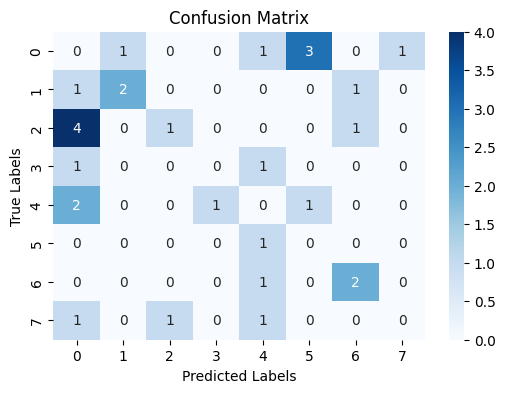

In [24]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Buat confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

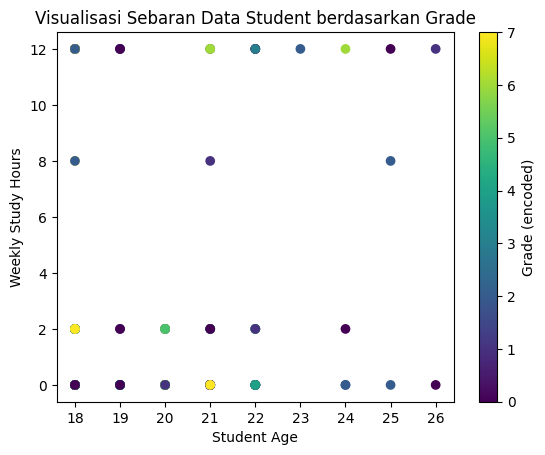

In [25]:
plt.scatter(
    df['Student_Age'],
    df['Weekly_Study_Hours'],
    c=y_encoded,
    cmap='viridis'
)
plt.xlabel('Student Age')
plt.ylabel('Weekly Study Hours')
plt.title('Visualisasi Sebaran Data Student berdasarkan Grade')
plt.colorbar(label='Grade (encoded)')
plt.show()


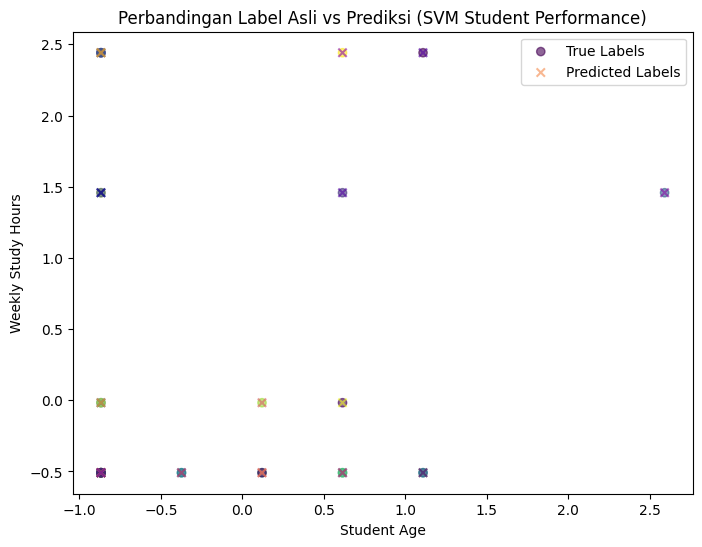

In [28]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# ambil data test dalam bentuk DataFrame agar bisa diakses kolomnya
X_test_df = pd.DataFrame(X_test, columns=X_encoded.columns)

plt.figure(figsize=(8,6))
plt.scatter(X_test_df['Student_Age'], X_test_df['Weekly_Study_Hours'],
            c=y_test, cmap='viridis', marker='o', label='True Labels', alpha=0.6)
plt.scatter(X_test_df['Student_Age'], X_test_df['Weekly_Study_Hours'],
            c=y_pred, cmap='plasma', marker='x', label='Predicted Labels', alpha=0.6)
plt.xlabel('Student Age')
plt.ylabel('Weekly Study Hours')
plt.title('Perbandingan Label Asli vs Prediksi (SVM Student Performance)')
plt.legend()
plt.show()


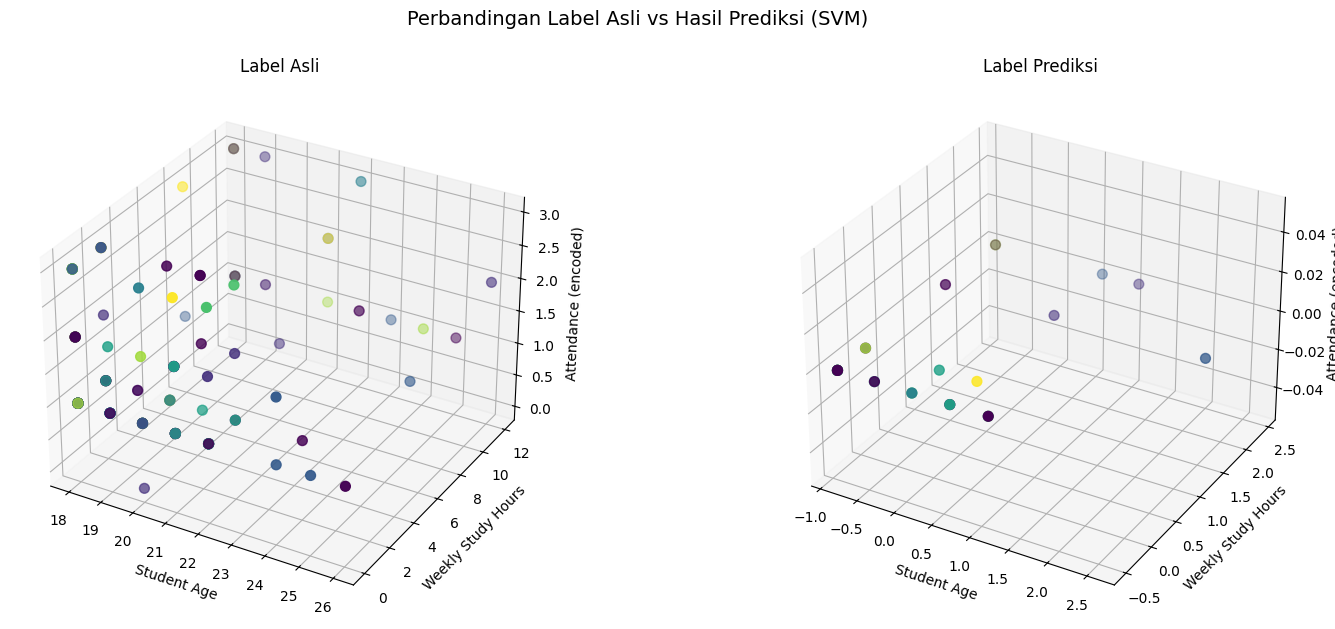

In [32]:
# Buat salinan dataframe supaya aman
df_vis = df.copy()

# Encode kolom Attendance (karena berisi string seperti 'Always', 'Sometimes', dll)
le_att = LabelEncoder()
df_vis['Attendance_Encoded'] = le_att.fit_transform(df_vis['Attendance'])

# Buat figure 3D
fig = plt.figure(figsize=(18, 7))

# Plot 1 — Label Asli
# --------------------------
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(
    df_vis['Student_Age'],
    df_vis['Weekly_Study_Hours'],
    df_vis['Attendance_Encoded'],
    c=y_encoded, cmap='viridis', s=50
)
ax1.set_title('Label Asli')
ax1.set_xlabel('Student Age')
ax1.set_ylabel('Weekly Study Hours')
ax1.set_zlabel('Attendance (encoded)')

# Plot 2 — Label Prediksi
# --------------------------
ax2 = fig.add_subplot(122, projection='3d')

# Buat salinan X_test untuk menambahkan label prediksi
import pandas as pd
X_test_vis = pd.DataFrame(X_test, columns=X.columns)
X_test_vis['Predicted_Grade'] = y_pred

ax2.scatter(
    X_test_vis['Student_Age'],
    X_test_vis['Weekly_Study_Hours'],
    X_test_vis['Attendance_Encoded'] if 'Attendance_Encoded' in X_test_vis.columns else 0,
    c=y_pred, cmap='viridis', s=50
)

ax2.set_title('Label Prediksi')
ax2.set_xlabel('Student Age')
ax2.set_ylabel('Weekly Study Hours')
ax2.set_zlabel('Attendance (encoded)')

plt.suptitle('Perbandingan Label Asli vs Hasil Prediksi (SVM)', fontsize=14)
plt.show()
